# Self-Supervised Visual Representation Learning with SimCLR

## Goal

This notebook explores self-supervised learning using a small SimCLR-style contrastive learning task on Fashion-MNIST.

The main question is:

Can a CNN learn useful image representations without using labels during pretraining?

## Project idea

Instead of training directly with class labels, the model first learns by comparing augmented versions of the same image.

During self-supervised pretraining:

- The model sees two different augmented views of the same image.
- These two views form a positive pair.
- Other images in the batch act as negative examples.
- The model learns an embedding space where similar views of the same image are close together.

After pretraining, the encoder is frozen and evaluated using a simple linear classifier.

In [36]:
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, Subset, Dataset, random_split
from torchvision import datasets, transforms

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [77]:
DATA_DIR = Path("../../data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 256
NUM_WORKERS = 0

SSL_SUBSET_SIZE = 20000
LINEAR_PROBE_SIZE = 5000
TEST_SUBSET_SIZE = 10000

SSL_EPOCHS = 15
LINEAR_EPOCHS = 15
SUPERVISED_EPOCHS = 15

EMBEDDING_DIM = 128
PROJECTION_DIM = 64
TEMPERATURE = 0.5

## Configuration note

This notebook uses a compact Fashion-MNIST self-supervised learning setup to keep training time manageable.

The self-supervised pretraining stage uses 20,000 unlabelled training images. The linear probe and supervised CNN baseline both use 5,000 labelled training images, and final evaluation is done on the full 10,000-image test set.

The experiment was trained for 15 epochs in each stage:

- Self-supervised pretraining: 15 epochs
- Linear probe training: 15 epochs
- Supervised baseline training: 15 epochs

The notebook used CUDA, so training was run on GPU.

In [38]:
base_train_dataset = datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=None
)

base_test_dataset = datasets.FashionMNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=None
)

class_names = base_train_dataset.classes

print("Train size:", len(base_train_dataset))
print("Test size:", len(base_test_dataset))
print("Classes:", class_names)

Train size: 60000
Test size: 10000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


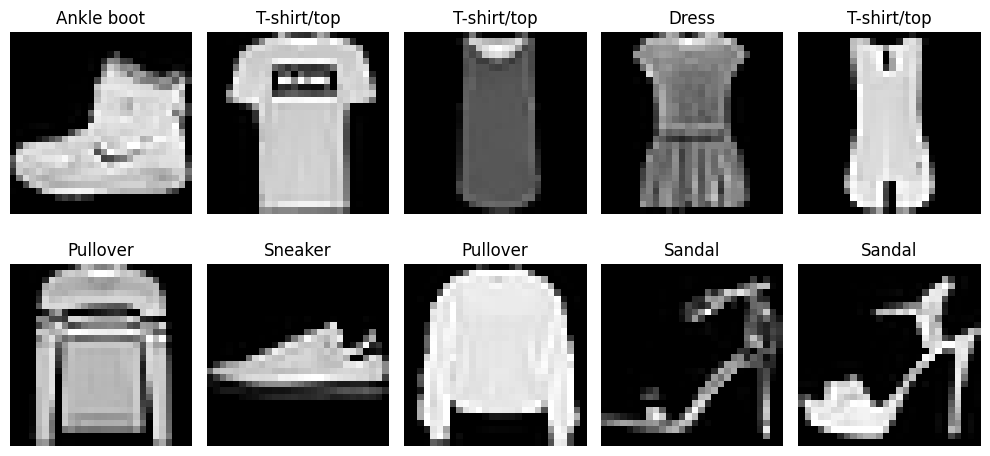

In [39]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for ax, idx in zip(axes.ravel(), range(10)):
    image, label = base_train_dataset[idx]
    ax.imshow(image, cmap="gray")
    ax.set_title(class_names[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

## Dataset

Fashion-MNIST contains 60,000 training images and 10,000 test images.

Each image is a 28 by 28 grayscale image belonging to one of 10 clothing categories:

- T-shirt/top
- Trouser
- Pullover
- Dress
- Coat
- Sandal
- Shirt
- Sneaker
- Bag
- Ankle boot

This dataset is suitable for a self-supervised learning experiment because the images are small enough to train quickly, but the classes still contain meaningful visual similarities and differences.

In [40]:
ssl_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=28, scale=(0.65, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

standard_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

## Augmentation note

The self-supervised transform creates two different views of the same image using random resized cropping, horizontal flipping, and random rotation.

These augmentations create the positive pairs used during contrastive learning. The model is encouraged to recognise that two changed versions of the same clothing item should still have similar representations.

The augmentations are not too extreme, so the main object usually remains recognisable.

In [41]:
class ContrastiveFashionMNIST(Dataset):
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform
    
    def __len__(self):
        return len(self.base_dataset)
    
    def __getitem__(self, idx):
        image, _ = self.base_dataset[idx]
        
        view_1 = self.transform(image)
        view_2 = self.transform(image)
        
        return view_1, view_2

In [42]:
class StandardFashionMNIST(Dataset):
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform
    
    def __len__(self):
        return len(self.base_dataset)
    
    def __getitem__(self, idx):
        image, label = self.base_dataset[idx]
        image = self.transform(image)
        return image, label

In [43]:
all_train_indices = np.arange(len(base_train_dataset))
np.random.shuffle(all_train_indices)

ssl_indices = all_train_indices[:SSL_SUBSET_SIZE]
linear_indices = all_train_indices[SSL_SUBSET_SIZE:SSL_SUBSET_SIZE + LINEAR_PROBE_SIZE]

test_indices = np.arange(min(TEST_SUBSET_SIZE, len(base_test_dataset)))

ssl_dataset = ContrastiveFashionMNIST(
    Subset(base_train_dataset, ssl_indices),
    transform=ssl_transform
)

linear_train_dataset = StandardFashionMNIST(
    Subset(base_train_dataset, linear_indices),
    transform=standard_transform
)

test_dataset = StandardFashionMNIST(
    Subset(base_test_dataset, test_indices),
    transform=standard_transform
)

ssl_loader = DataLoader(
    ssl_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    drop_last=True
)

linear_train_loader = DataLoader(
    linear_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("SSL dataset size:", len(ssl_dataset))
print("Linear probe dataset size:", len(linear_train_dataset))
print("Test dataset size:", len(test_dataset))

SSL dataset size: 20000
Linear probe dataset size: 5000
Test dataset size: 10000


## Dataset split note

The self-supervised encoder was pretrained on 20,000 unlabelled images.

The linear probe was trained on 5,000 labelled images.

The test set contained 10,000 images.

This setup tests whether the encoder can learn useful visual features before seeing labels. The labels are only used later when training the linear classifier on top of the frozen encoder.

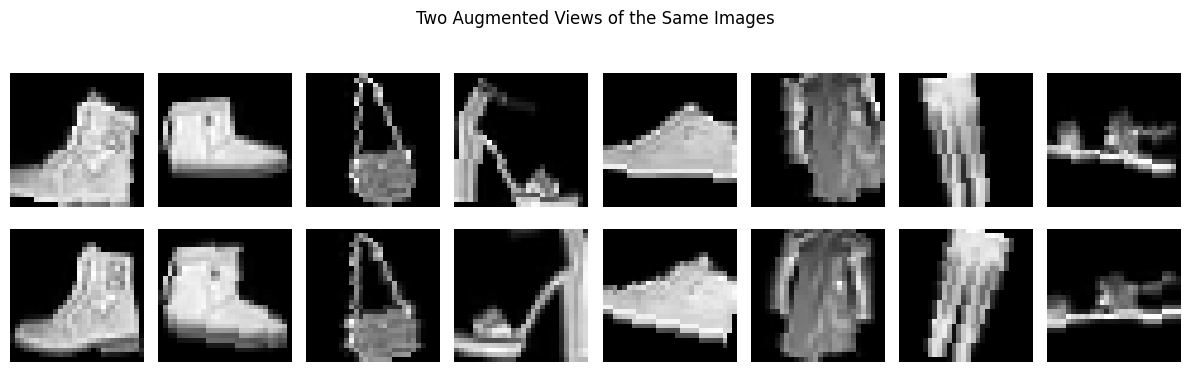

In [44]:
view_1, view_2 = next(iter(ssl_loader))

fig, axes = plt.subplots(2, 8, figsize=(12, 4))

for i in range(8):
    axes[0, i].imshow(view_1[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")
    
    axes[1, i].imshow(view_2[i].squeeze(), cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("View 1")
axes[1, 0].set_ylabel("View 2")

plt.suptitle("Two Augmented Views of the Same Images")
plt.tight_layout()
plt.show()

## Augmented pairs 

The augmented pair examples show two different transformed views of the same original image.

Most pairs still preserve the main clothing shape, even though cropping, flipping, and rotation slightly change the image.

This is important because contrastive learning depends on the two views being different enough to create a learning task, but not so different that the object identity is lost.

In [45]:
class SmallCNNEncoder(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            
            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        self.embedding = nn.Linear(128, embedding_dim)
    
    def forward(self, x):
        x = self.features(x)
        x = x.flatten(start_dim=1)
        x = self.embedding(x)
        return x

In [46]:
class ProjectionHead(nn.Module):
    def __init__(self, embedding_dim=128, projection_dim=64):
        super().__init__()
        
        self.projector = nn.Sequential(
            nn.Linear(embedding_dim, embedding_dim),
            nn.ReLU(),
            nn.Linear(embedding_dim, projection_dim)
        )
    
    def forward(self, x):
        return self.projector(x)

In [47]:
class SimCLRModel(nn.Module):
    def __init__(self, embedding_dim=128, projection_dim=64):
        super().__init__()
        
        self.encoder = SmallCNNEncoder(embedding_dim=embedding_dim)
        self.projection_head = ProjectionHead(
            embedding_dim=embedding_dim,
            projection_dim=projection_dim
        )
    
    def forward(self, x):
        embeddings = self.encoder(x)
        projections = self.projection_head(embeddings)
        projections = F.normalize(projections, dim=1)
        return embeddings, projections

In [48]:
ssl_model = SimCLRModel(
    embedding_dim=EMBEDDING_DIM,
    projection_dim=PROJECTION_DIM
).to(device)

ssl_model

SimCLRModel(
  (encoder): SmallCNNEncoder(
    (features): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
      (11): AdaptiveAvgPool2d(output_size=(1, 1))
    )
    (embedding): Linear(in_features=128, out_features=128, bias=True)
  )
  (projection_head): ProjectionHead(
    (projector): Sequential(
 

## Model architecture 

The model contains two main parts:

1. A CNN encoder
2. A projection head

The CNN encoder converts each image into a 128-dimensional embedding.

The projection head converts the embedding into a 64-dimensional contrastive representation used for the NT-Xent loss.

After self-supervised pretraining, the projection head is not used for classification. Only the encoder is kept and evaluated using a linear probe.

In [49]:
def nt_xent_loss(z1, z2, temperature=0.5):
    batch_size = z1.size(0)
    
    z = torch.cat([z1, z2], dim=0)
    z = F.normalize(z, dim=1)
    
    similarity_matrix = torch.matmul(z, z.T) / temperature
    
    mask = torch.eye(2 * batch_size, dtype=torch.bool, device=z.device)
    similarity_matrix = similarity_matrix.masked_fill(mask, -9e15)
    
    positive_indices = torch.cat([
        torch.arange(batch_size, 2 * batch_size),
        torch.arange(0, batch_size)
    ]).to(z.device)
    
    loss = F.cross_entropy(similarity_matrix, positive_indices)
    
    return loss

## Contrastive loss note

The NT-Xent loss is the main self-supervised learning objective.

It encourages two augmented views of the same image to have similar representations, while pushing representations of different images in the batch away from each other.

This allows the model to learn visual representations without using class labels during pretraining.

In [50]:
def train_ssl_one_epoch(model, dataloader, optimizer, temperature):
    model.train()
    
    total_loss = 0
    
    for view_1, view_2 in dataloader:
        view_1 = view_1.to(device)
        view_2 = view_2.to(device)
        
        _, z1 = model(view_1)
        _, z2 = model(view_2)
        
        loss = nt_xent_loss(z1, z2, temperature=temperature)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

In [78]:
ssl_optimizer = torch.optim.Adam(
    ssl_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

ssl_history = []

for epoch in range(1, SSL_EPOCHS + 1):
    train_loss = train_ssl_one_epoch(
        model=ssl_model,
        dataloader=ssl_loader,
        optimizer=ssl_optimizer,
        temperature=TEMPERATURE
    )
    
    ssl_history.append({
        "epoch": epoch,
        "ssl_loss": train_loss
    })
    
    print(f"Epoch {epoch:02d}/{SSL_EPOCHS} | SSL Loss: {train_loss:.4f}")

Epoch 01/15 | SSL Loss: 4.4347
Epoch 02/15 | SSL Loss: 4.4274
Epoch 03/15 | SSL Loss: 4.4217
Epoch 04/15 | SSL Loss: 4.4211
Epoch 05/15 | SSL Loss: 4.4191
Epoch 06/15 | SSL Loss: 4.4172
Epoch 07/15 | SSL Loss: 4.4140
Epoch 08/15 | SSL Loss: 4.4146
Epoch 09/15 | SSL Loss: 4.4151
Epoch 10/15 | SSL Loss: 4.4110
Epoch 11/15 | SSL Loss: 4.4109
Epoch 12/15 | SSL Loss: 4.4102
Epoch 13/15 | SSL Loss: 4.4100
Epoch 14/15 | SSL Loss: 4.4087
Epoch 15/15 | SSL Loss: 4.4084


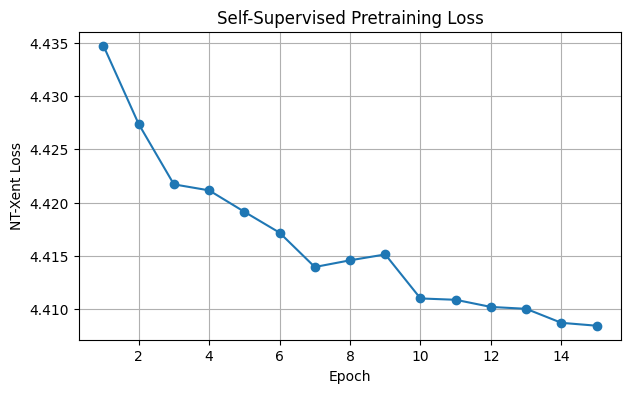

In [79]:
ssl_history_df = pd.DataFrame(ssl_history)

plt.figure(figsize=(7, 4))
plt.plot(ssl_history_df["epoch"], ssl_history_df["ssl_loss"], marker="o")
plt.title("Self-Supervised Pretraining Loss")
plt.xlabel("Epoch")
plt.ylabel("NT-Xent Loss")
plt.grid(True)
plt.show()

## Self-supervised pretraining 

The self-supervised contrastive loss decreased slightly from 4.4347 in epoch 1 to 4.4084 in epoch 15.

The decrease is not large, but it shows that the model was learning some consistency between augmented views.

Because this is a small educational SimCLR-style setup with a small CNN, limited epochs, grayscale images, and a moderate batch size, the contrastive loss is not expected to drop dramatically. The more important test is whether the frozen encoder produces useful features for the linear probe.

In [80]:
class LinearProbe(nn.Module):
    def __init__(self, encoder, embedding_dim=128, num_classes=10):
        super().__init__()
        
        self.encoder = encoder
        
        for param in self.encoder.parameters():
            param.requires_grad = False
        
        self.classifier = nn.Linear(embedding_dim, num_classes)
    
    def forward(self, x):
        with torch.no_grad():
            embeddings = self.encoder(x)
        
        logits = self.classifier(embeddings)
        return logits

In [81]:
linear_probe = LinearProbe(
    encoder=ssl_model.encoder,
    embedding_dim=EMBEDDING_DIM,
    num_classes=10
).to(device)

linear_probe

LinearProbe(
  (encoder): SmallCNNEncoder(
    (features): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
      (11): AdaptiveAvgPool2d(output_size=(1, 1))
    )
    (embedding): Linear(in_features=128, out_features=128, bias=True)
  )
  (classifier): Linear(in_features=128, out_features=10, bias=True)

In [82]:
def train_classifier_one_epoch(model, dataloader, optimizer, criterion):
    model.train()
    
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        
        logits = model(images)
        loss = criterion(logits, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    
    return avg_loss, accuracy

In [83]:
def evaluate_classifier(model, dataloader, criterion=None):
    model.eval()
    
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            
            logits = model(images)
            
            if criterion is not None:
                loss = criterion(logits, labels)
                total_loss += loss.item()
            
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    
    if criterion is not None:
        avg_loss = total_loss / len(dataloader)
    else:
        avg_loss = None
    
    return avg_loss, accuracy, np.array(all_labels), np.array(all_preds)

In [84]:
criterion = nn.CrossEntropyLoss()

linear_optimizer = torch.optim.Adam(
    linear_probe.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

linear_history = []

for epoch in range(1, LINEAR_EPOCHS + 1):
    train_loss, train_acc = train_classifier_one_epoch(
        model=linear_probe,
        dataloader=linear_train_loader,
        optimizer=linear_optimizer,
        criterion=criterion
    )
    
    test_loss, test_acc, _, _ = evaluate_classifier(
        model=linear_probe,
        dataloader=test_loader,
        criterion=criterion
    )
    
    linear_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "test_loss": test_loss,
        "test_accuracy": test_acc
    })
    
    print(
        f"Epoch {epoch:02d}/{LINEAR_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

Epoch 01/15 | Train Loss: 2.1991 | Train Acc: 0.2096 | Test Acc: 0.3158
Epoch 02/15 | Train Loss: 2.0104 | Train Acc: 0.4114 | Test Acc: 0.4550
Epoch 03/15 | Train Loss: 1.8724 | Train Acc: 0.4736 | Test Acc: 0.4906
Epoch 04/15 | Train Loss: 1.7642 | Train Acc: 0.5134 | Test Acc: 0.5428
Epoch 05/15 | Train Loss: 1.6748 | Train Acc: 0.5486 | Test Acc: 0.5732
Epoch 06/15 | Train Loss: 1.6035 | Train Acc: 0.5622 | Test Acc: 0.5857
Epoch 07/15 | Train Loss: 1.5437 | Train Acc: 0.5846 | Test Acc: 0.5919
Epoch 08/15 | Train Loss: 1.4902 | Train Acc: 0.5954 | Test Acc: 0.6096
Epoch 09/15 | Train Loss: 1.4469 | Train Acc: 0.6010 | Test Acc: 0.6160
Epoch 10/15 | Train Loss: 1.4074 | Train Acc: 0.6104 | Test Acc: 0.6232
Epoch 11/15 | Train Loss: 1.3721 | Train Acc: 0.6178 | Test Acc: 0.6282
Epoch 12/15 | Train Loss: 1.3416 | Train Acc: 0.6254 | Test Acc: 0.6326
Epoch 13/15 | Train Loss: 1.3146 | Train Acc: 0.6194 | Test Acc: 0.6328
Epoch 14/15 | Train Loss: 1.2922 | Train Acc: 0.6294 | Test Acc:

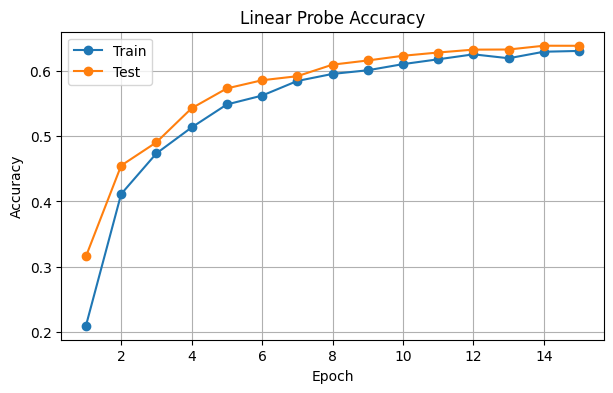

In [85]:
linear_history_df = pd.DataFrame(linear_history)

plt.figure(figsize=(7, 4))
plt.plot(linear_history_df["epoch"], linear_history_df["train_accuracy"], marker="o", label="Train")
plt.plot(linear_history_df["epoch"], linear_history_df["test_accuracy"], marker="o", label="Test")
plt.title("Linear Probe Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Linear probe 

The linear probe tests whether the frozen self-supervised encoder learned useful visual features.

The linear probe accuracy improved from 31.58% in epoch 1 to 63.85% in the final evaluation.

This is much better than random guessing, which would be around 10% for 10 classes. This suggests that the self-supervised encoder learned meaningful visual structure even though it did not use labels during pretraining.

However, the final accuracy is still moderate, meaning the learned representations are useful but not strong enough to fully separate all clothing categories.

In [86]:
class SupervisedCNN(nn.Module):
    def __init__(self, embedding_dim=128, num_classes=10):
        super().__init__()
        
        self.encoder = SmallCNNEncoder(embedding_dim=embedding_dim)
        self.classifier = nn.Linear(embedding_dim, num_classes)
    
    def forward(self, x):
        embeddings = self.encoder(x)
        logits = self.classifier(embeddings)
        return logits

In [87]:
supervised_model = SupervisedCNN(
    embedding_dim=EMBEDDING_DIM,
    num_classes=10
).to(device)

supervised_optimizer = torch.optim.Adam(
    supervised_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

supervised_history = []

for epoch in range(1, SUPERVISED_EPOCHS + 1):
    train_loss, train_acc = train_classifier_one_epoch(
        model=supervised_model,
        dataloader=linear_train_loader,
        optimizer=supervised_optimizer,
        criterion=criterion
    )
    
    test_loss, test_acc, _, _ = evaluate_classifier(
        model=supervised_model,
        dataloader=test_loader,
        criterion=criterion
    )
    
    supervised_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "test_loss": test_loss,
        "test_accuracy": test_acc
    })
    
    print(
        f"Epoch {epoch:02d}/{SUPERVISED_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

Epoch 01/15 | Train Loss: 1.6982 | Train Acc: 0.4386 | Test Acc: 0.3583
Epoch 02/15 | Train Loss: 1.0307 | Train Acc: 0.6718 | Test Acc: 0.7017
Epoch 03/15 | Train Loss: 0.7772 | Train Acc: 0.7244 | Test Acc: 0.6720
Epoch 04/15 | Train Loss: 0.6566 | Train Acc: 0.7612 | Test Acc: 0.7078
Epoch 05/15 | Train Loss: 0.5788 | Train Acc: 0.7842 | Test Acc: 0.7187
Epoch 06/15 | Train Loss: 0.5267 | Train Acc: 0.8076 | Test Acc: 0.6384
Epoch 07/15 | Train Loss: 0.4721 | Train Acc: 0.8320 | Test Acc: 0.7821
Epoch 08/15 | Train Loss: 0.4393 | Train Acc: 0.8418 | Test Acc: 0.7374
Epoch 09/15 | Train Loss: 0.4120 | Train Acc: 0.8508 | Test Acc: 0.7997
Epoch 10/15 | Train Loss: 0.3779 | Train Acc: 0.8656 | Test Acc: 0.7648
Epoch 11/15 | Train Loss: 0.3523 | Train Acc: 0.8760 | Test Acc: 0.7116
Epoch 12/15 | Train Loss: 0.3361 | Train Acc: 0.8812 | Test Acc: 0.7937
Epoch 13/15 | Train Loss: 0.3125 | Train Acc: 0.8906 | Test Acc: 0.7537
Epoch 14/15 | Train Loss: 0.3326 | Train Acc: 0.8764 | Test Acc:

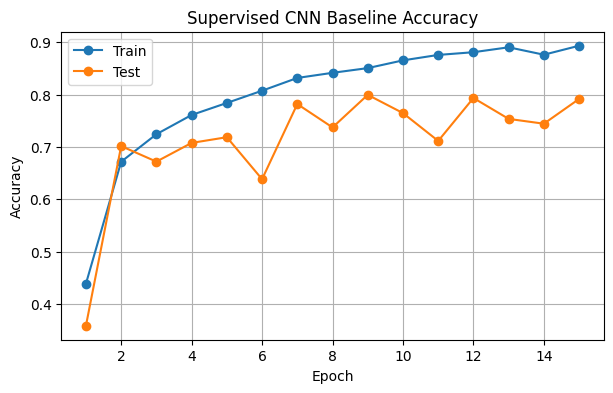

In [88]:
supervised_history_df = pd.DataFrame(supervised_history)

plt.figure(figsize=(7, 4))
plt.plot(supervised_history_df["epoch"], supervised_history_df["train_accuracy"], marker="o", label="Train")
plt.plot(supervised_history_df["epoch"], supervised_history_df["test_accuracy"], marker="o", label="Test")
plt.title("Supervised CNN Baseline Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Supervised baseline 

The supervised CNN baseline was trained directly with class labels using the same 5,000 labelled images as the linear probe.

It achieved a final test accuracy of 79.19%, which is clearly higher than the self-supervised encoder with linear probe.

The supervised model also reached a peak test accuracy of 79.97% during training.

This result makes sense because the supervised CNN directly optimises for the classification task, while the self-supervised model first learns general image representations and only later uses labels through a frozen linear classifier.

In [89]:
linear_test_loss, linear_test_acc, linear_y_true, linear_y_pred = evaluate_classifier(
    model=linear_probe,
    dataloader=test_loader,
    criterion=criterion
)

supervised_test_loss, supervised_test_acc, supervised_y_true, supervised_y_pred = evaluate_classifier(
    model=supervised_model,
    dataloader=test_loader,
    criterion=criterion
)

comparison_df = pd.DataFrame([
    {
        "model": "Self-Supervised Encoder + Linear Probe",
        "test_loss": linear_test_loss,
        "test_accuracy": linear_test_acc
    },
    {
        "model": "Supervised CNN Baseline",
        "test_loss": supervised_test_loss,
        "test_accuracy": supervised_test_acc
    }
])

comparison_df

,model,test_loss,test_accuracy
0,Self-Supervised Encoder + Linear Probe,1.255676,0.6385
1,Supervised CNN Baseline,0.607761,0.7919


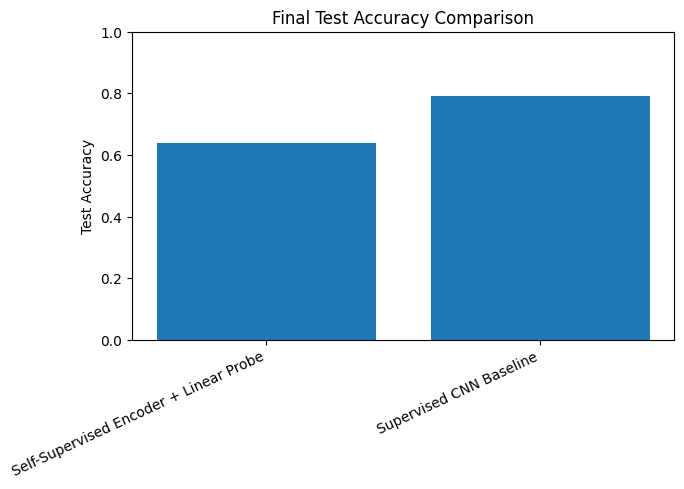

In [90]:
plt.figure(figsize=(7, 4))
plt.bar(comparison_df["model"], comparison_df["test_accuracy"])
plt.title("Final Test Accuracy Comparison")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.show()

## Final comparison 

The self-supervised encoder with a linear probe achieved:

- Test loss: 1.2557
- Test accuracy: 63.85%

The supervised CNN baseline achieved:

- Test loss: 0.6078
- Test accuracy: 79.19%

The supervised CNN baseline performed better overall.

However, the self-supervised model still learned useful representations without labels during pretraining. Its 63.85% test accuracy is well above random guessing, showing that contrastive learning captured meaningful visual information about clothing shape and category similarity.

In [91]:
print("Self-Supervised Encoder + Linear Probe")
print(classification_report(
    linear_y_true,
    linear_y_pred,
    target_names=class_names
))

Self-Supervised Encoder + Linear Probe
              precision    recall  f1-score   support

 T-shirt/top       0.55      0.55      0.55      1000
     Trouser       0.86      0.91      0.88      1000
    Pullover       0.53      0.35      0.42      1000
       Dress       0.65      0.62      0.63      1000
        Coat       0.44      0.53      0.48      1000
      Sandal       0.70      0.83      0.76      1000
       Shirt       0.29      0.28      0.28      1000
     Sneaker       0.79      0.79      0.79      1000
         Bag       0.83      0.76      0.79      1000
  Ankle boot       0.74      0.77      0.76      1000

    accuracy                           0.64     10000
   macro avg       0.64      0.64      0.63     10000
weighted avg       0.64      0.64      0.63     10000



In [92]:
print("Supervised CNN Baseline")
print(classification_report(
    supervised_y_true,
    supervised_y_pred,
    target_names=class_names
))

Supervised CNN Baseline
              precision    recall  f1-score   support

 T-shirt/top       0.62      0.93      0.74      1000
     Trouser       1.00      0.90      0.95      1000
    Pullover       0.65      0.85      0.73      1000
       Dress       0.81      0.82      0.81      1000
        Coat       0.83      0.50      0.62      1000
      Sandal       0.90      0.91      0.91      1000
       Shirt       0.65      0.43      0.52      1000
     Sneaker       0.98      0.64      0.77      1000
         Bag       0.94      0.96      0.95      1000
  Ankle boot       0.74      0.99      0.85      1000

    accuracy                           0.79     10000
   macro avg       0.81      0.79      0.79     10000
weighted avg       0.81      0.79      0.79     10000



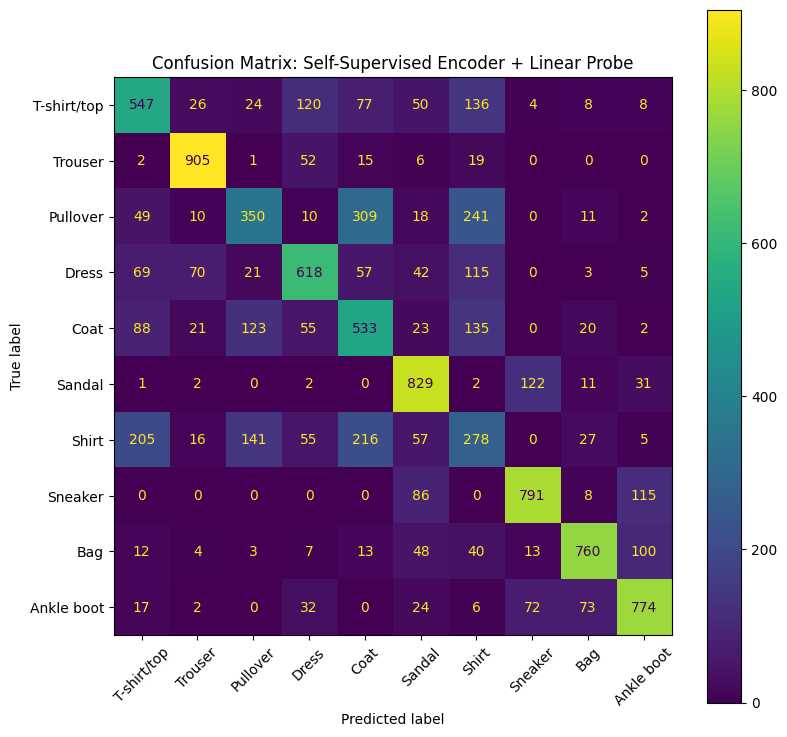

In [93]:
cm = confusion_matrix(linear_y_true, linear_y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(9, 9))
display.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix: Self-Supervised Encoder + Linear Probe")
plt.show()

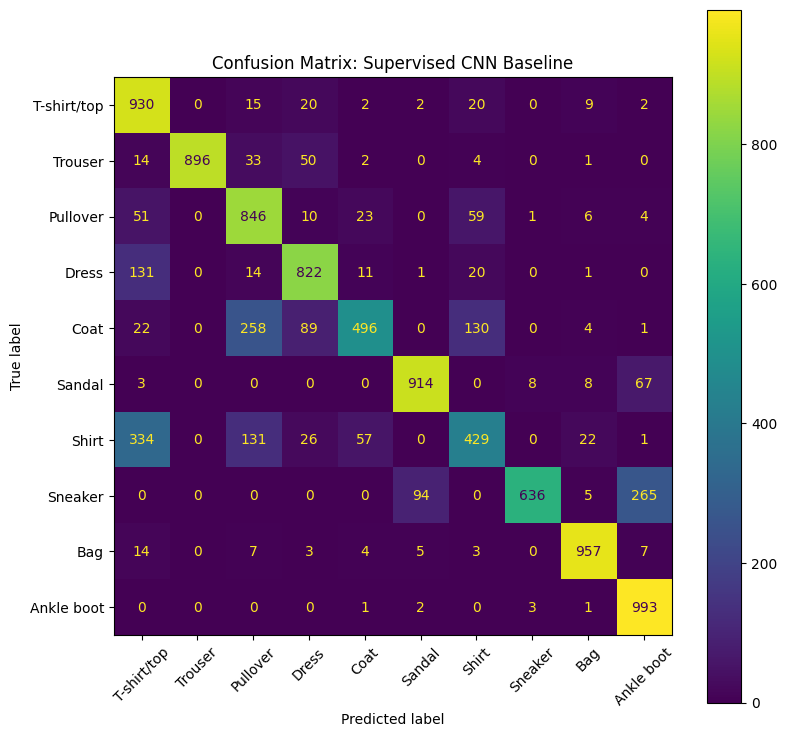

In [94]:
cm = confusion_matrix(supervised_y_true, supervised_y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(9, 9))
display.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix: Supervised CNN Baseline")
plt.show()

## Classification report 

For the self-supervised encoder with linear probe, the easiest classes were:

- Trouser, with an F1-score of 0.88
- Bag, with an F1-score of 0.79
- Sneaker, with an F1-score of 0.79
- Sandal and Ankle boot, both with F1-scores around 0.76

The hardest classes were:

- Shirt, with an F1-score of 0.28
- Pullover, with an F1-score of 0.42
- Coat, with an F1-score of 0.48

The main confusions were between visually similar upper-body clothing categories. For example, shirts, pullovers, coats, and T-shirts were often confused with each other.

For the supervised CNN baseline, performance improved across most classes. Trouser, Bag, Sandal, and Ankle boot were classified especially well. However, Shirt and Coat remained difficult, which shows that these categories are visually similar even for the supervised model.

In [95]:
def extract_embeddings(encoder, dataloader):
    encoder.eval()
    
    all_embeddings = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            
            embeddings = encoder(images)
            
            all_embeddings.append(embeddings.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    all_embeddings = np.concatenate(all_embeddings, axis=0)
    all_labels = np.array(all_labels)
    
    return all_embeddings, all_labels

In [96]:
ssl_embeddings, embedding_labels = extract_embeddings(
    encoder=ssl_model.encoder,
    dataloader=test_loader
)

ssl_embeddings.shape

(10000, 128)

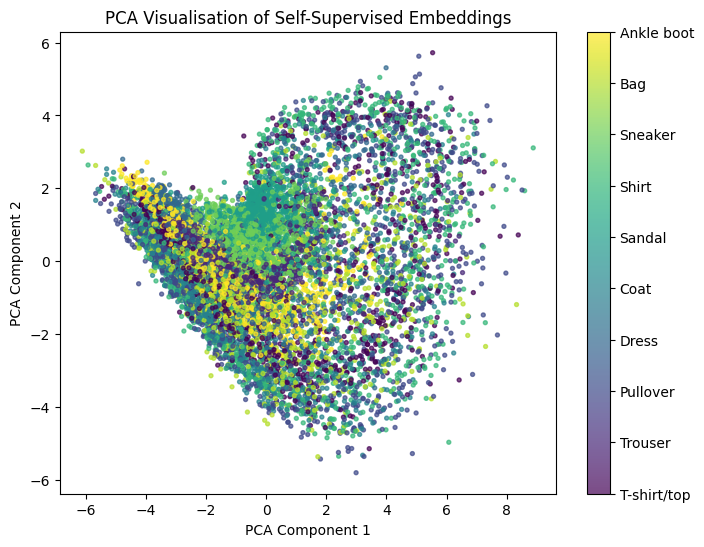

In [97]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)

embeddings_2d = pca.fit_transform(ssl_embeddings)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=embedding_labels,
    s=8,
    alpha=0.7
)

plt.title("PCA Visualisation of Self-Supervised Embeddings")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

cbar = plt.colorbar(scatter, ticks=range(10))
cbar.ax.set_yticklabels(class_names)

plt.show()

## Embedding visualisation 

The PCA plot shows that the self-supervised embeddings contain some visual structure, but the classes are not cleanly separated in two dimensions.

Some regions of the plot contain partial grouping, but there is also substantial overlap between classes. This is expected because PCA compresses 128-dimensional embeddings into only two dimensions, so some information is lost.

The overlap also matches the classification results. The encoder learned useful representations, but the linear probe still struggled with visually similar clothing categories such as shirt, coat, pullover, and T-shirt/top.

In [98]:
def collect_prediction_examples(model, dataloader, max_batches=5):
    model.eval()
    
    images_list = []
    labels_list = []
    preds_list = []
    
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(dataloader):
            images = images.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1).cpu()
            
            images_list.append(images.cpu())
            labels_list.append(labels)
            preds_list.append(preds)
            
            if batch_idx + 1 >= max_batches:
                break
    
    images = torch.cat(images_list)
    labels = torch.cat(labels_list)
    preds = torch.cat(preds_list)
    
    return images, labels, preds

In [99]:
example_images, example_labels, example_preds = collect_prediction_examples(
    model=linear_probe,
    dataloader=test_loader
)

correct_mask = example_labels == example_preds
incorrect_mask = example_labels != example_preds

correct_indices = torch.where(correct_mask)[0][:8]
incorrect_indices = torch.where(incorrect_mask)[0][:8]

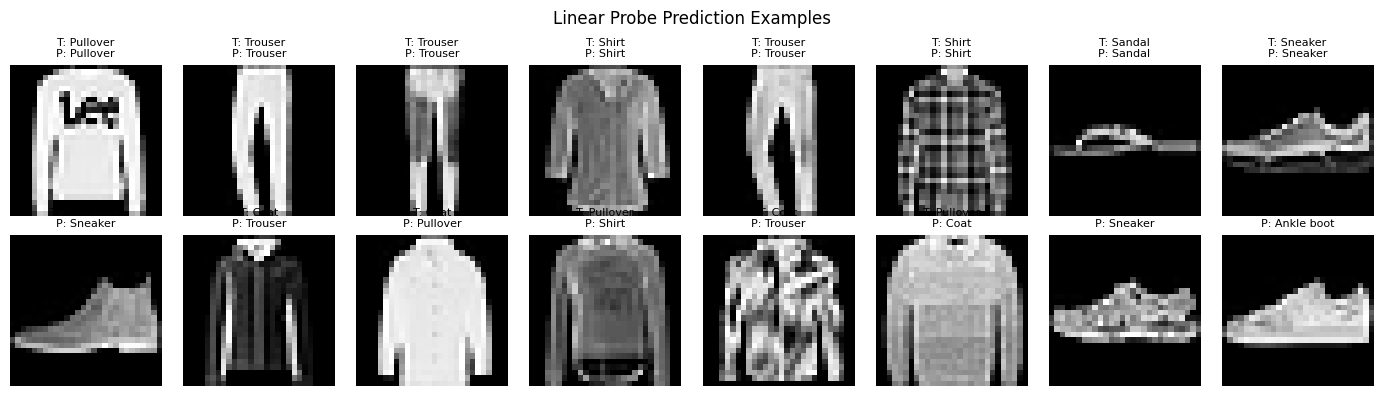

In [100]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))

for ax, idx in zip(axes[0], correct_indices):
    image = example_images[idx].squeeze()
    true_label = class_names[example_labels[idx]]
    pred_label = class_names[example_preds[idx]]
    
    ax.imshow(image, cmap="gray")
    ax.set_title(f"T: {true_label}\nP: {pred_label}", fontsize=8)
    ax.axis("off")

for ax, idx in zip(axes[1], incorrect_indices):
    image = example_images[idx].squeeze()
    true_label = class_names[example_labels[idx]]
    pred_label = class_names[example_preds[idx]]
    
    ax.imshow(image, cmap="gray")
    ax.set_title(f"T: {true_label}\nP: {pred_label}", fontsize=8)
    ax.axis("off")

axes[0, 0].set_ylabel("Correct")
axes[1, 0].set_ylabel("Incorrect")

plt.suptitle("Linear Probe Prediction Examples")
plt.tight_layout()
plt.show()

## Prediction examples

The correct prediction examples usually have clear and distinctive shapes, such as trousers, sandals, sneakers, and some upper-body clothing items.

The incorrect examples mostly involve visually similar categories. For example, sneakers can be confused with ankle boots, and coats, pullovers, shirts, and T-shirts can be confused with one another.

This matches the confusion matrix and classification report. The model learned broad visual structure, but it still struggles with fine-grained differences between similar clothing types.